# 基本版本

**内容整体上和 3_MLP_makemore.ipynb 差不多，但是对一些细节进行了优化**

In [26]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) 
  h = torch.tanh(embcat @ W1 + b1) 
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline
words = open('names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [30]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) 
C  = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) 
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g) 
b2 = torch.randn(vocab_size,  generator=g) 
parameters = [C, W1,b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

11897


In [31]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb]
  embcat = emb.view(emb.shape[0], -1) 
  h = torch.tanh(embcat @ W1 + b1) 
  logits = h @ W2 + b2 
  loss = F.cross_entropy(logits, Yb)
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 27.8817
  10000/ 200000: 2.8483
  20000/ 200000: 2.5429
  30000/ 200000: 2.7459
  40000/ 200000: 2.1223
  50000/ 200000: 2.5109
  60000/ 200000: 2.4267
  70000/ 200000: 2.1317
  80000/ 200000: 2.3420
  90000/ 200000: 2.2789
 100000/ 200000: 1.9640
 110000/ 200000: 2.4866
 120000/ 200000: 2.0835
 130000/ 200000: 2.4737
 140000/ 200000: 2.2107
 150000/ 200000: 2.1605
 160000/ 200000: 2.0494
 170000/ 200000: 1.7936
 180000/ 200000: 2.0382
 190000/ 200000: 1.7283


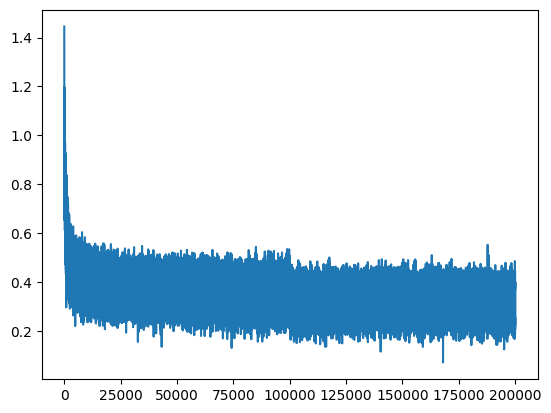

In [32]:
plt.plot(lossi)

In [33]:
split_loss('train')
split_loss('val')

train 2.122785806655884
val 2.1687753200531006


## 初始化分析

注意，
+ 上面这个代码，每1w次打印一次结果，一共运行了20w次，所以运行起来会有点耗时
+ 这里可以看到：
  + 没有优化之前，直接使用`torch.randn()`随机赋值的`W`和`b`参数构成的网络，损失值是 **27.8817**，比想象中要高很多
  + 正常我们对这个任务的期望，是认为，至少在初始化(`initialization`)阶段, 不应该出现某个字符比其他字符出现概率高得多的情况
  + 我们预期这个初始输出的概率分布，应该是均匀分布(`uniform`)
  + 对于这个预测下一个字符的任务，概率为$\frac{1}{27}$(这里本身已经不需要用`exp`转换, 同时也不需要用`count/sum(count)`来归一化，这个概率本身就是处理好的), 计算对应的损失函数, 应该是 `-log(1/27)`(这里也不用`mean()`了)
  + `-torch.tensor([1/27]).log() = 3.2958`
  + 但是很明显， 这个**随机初始化的网络的损失** 27.8817 要远远大于 **期望的正常的均匀分布的损失** 3.2958

即： 随机初始化的网络，导致对某些字符的预测置信度很高，有些则很低；

本质上，这种初始化的结果表现出的就是： 神经网络以极高的置信度在犯错

In [5]:
-torch.tensor([1/27]).log()

tensor([3.2958])

进一步使用以下示例进行说明：
+ 假设我们只有四个字符(词表是4个，即：输出的下一个字符只能从这4个里面选)
+ 有一个样本，其预测下一个字符的真值索引是`2`

In [18]:
logits = torch.tensor([0.0, 0.0, 0.0, 0.0])  # 对应的loss是 tensor(1.3863)
logits = torch.tensor([-3.0, 5.0, 0.0, 3.0]) # 对应的loss是 tensor(5.1331)
logits = torch.randn(4)                      # 对应的loss是 tensor(1.4865)
# 正态分布，大部分参数都在0附近
logits = torch.randn(4) * 10                 # 对应的loss是 tensor(12.7438)
logits = torch.tensor([1.0,1.0, 1.0, 1.0])
probs = torch.softmax(logits, dim = 0) # 对logits进行exp，这里只有一个样本，其实少写了一个[]，所以是在dim=0上进行的求和
loss = -probs[2].log()
print(probs, loss)

# 等价的简洁表达
logits = torch.tensor([[0.0, 0.0, 0.0, 0.0]])
Y = torch.tensor([2])
loss = F.cross_entropy(logits, Y)
print(loss)

tensor([0.2500, 0.2500, 0.2500, 0.2500]) tensor(1.3863)
tensor(1.3863)


In [13]:
-torch.tensor([1/4]).log()

tensor([1.3863])

所以**初始化网络应该输出一个均匀分布的结果**
+ 如果初始化的时候，网络里参数有很多极端值，那么就会导致初始loss很大，很不合理~  比如上面这个例子，`torch.randn(4) * 10`
+ 因此，一般我们希望网络初始化时，逻辑值可以大致为0；
  + 实际上，对于这个例子（**使用softmax/最大似然损失函数的**），不需要逻辑值一定是0，只需要所有的**逻辑值一样即可**, `logits = torch.tensor([1.0,1.0, 1.0, 1.0])`也可以
  + 但是处于对称性考虑，我们不希望是任意整数/负数
    ```bash
    Loss
     │
     │         ╲           ╱
     │          ╲         ╱
     │           ╲       ╱
     │            ╲     ╱
     │             ╲   ╱
     │              ╲ ╱
     │───────────────●──────────── Logits
                (0, 初始点)
    ```
    从 Loss 曲面的"中心"出发，优化器可以向任何方向自由探索。
    
    如果从极端偏移的位置出发，优化器需要先"走回来"，浪费训练时间，甚至陷入局部最优。

## 随机初始化的坏处

In [19]:
g = torch.Generator().manual_seed(2147483647) 
C  = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) 
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g) 
b2 = torch.randn(vocab_size,  generator=g) 
parameters = [C, W1,b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb]
  embcat = emb.view(emb.shape[0], -1) 
  h = torch.tanh(embcat @ W1 + b1) 
  logits = h @ W2 + b2 
  loss = F.cross_entropy(logits, Yb)
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  break

11897
      0/ 200000: 27.8817


In [20]:
logits[0]

tensor([ -2.3527,  36.4366, -10.7306,   5.7165,  18.6409, -11.6998,  -2.1991,
          1.8535,  10.9996,  10.6730,  12.3507, -10.3809,   4.7243, -24.4257,
         -8.5909,   1.9024, -12.2744, -12.4751, -23.2778,  -2.0163,  25.8767,
         14.2108,  17.7691, -10.9204, -20.7335,   6.4560,  11.1615],
       grad_fn=<SelectBackward0>)

可以看到，这个值都很极端。。。从[-24, 36], 值都很大，所以损失能直接到27

# 修改初始化方案

```bash
C  = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) 
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g) 
b2 = torch.randn(vocab_size,  generator=g) 

# forward pass
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1) 
h = torch.tanh(embcat @ W1 + b1) 
logits = h @ W2 + b2   
```
从前向过程可以做出以下决策：
1. `logits = h @ W2 + b2`， 想让`logits`为0，则`b2=0`→ `b2 = torch.randn(vocab_size,  generator=g) *0`
2. 想让`logits`为0，则`h @ W2 = 0`, 这里只能修改`W2`(`W2`本身是正态分布随机生成的，就在0附近了，为了更接近0，就乘上一个小数，变得更小) → `W2 = torch.randn((n_hidden, vocab_size), generator=g) *0.1`
3. 进行上述两个修改后，初始的损失就降低到了 `4.2326`，有了相当显著的改善
4. 甚至可以更小， `W2*0.01`, 得到的损失是： `3.3221`
   + 这里损失是`3.3221`，高于直接`1/27`对应的损失`3.2958` → 这种初始化方式带有一定的低熵(entropy), 将被用于打破对称性(symmetry breaking)
   + **什么是对称性灾难？** 假设你把网络中所有神经元的权重和偏置都初始化为**完全相同的值（比如全 0）**。那么在反向传播计算梯度时，每个神经元接收到的梯度也是完全一样的。这会导致在训练过程中，**所有神经元永远保持相同，同步更新**。它们就像是一个神经元的重复，无法学习到不同的特征，模型直接“瘫痪”。
   + **如何打破对称性？** 必须在初始化时引入**随机性或微小的差异**。
   + 通过将 logits 初始化为“带有微小差异的接近 0 的数字”，模型在初始状态下对各个类别的输出就有了微小的不同。这种微小的不同（低熵）打破了输出层的“对称性”。在随后的反向传播中，不同的输出节点会接收到不同的梯度，从而开始向不同的方向更新，学习到不同的特征。
6. 那么是否可以直接 `W2*0`呢？
   + 初始化的时候，通常我们希望神经网络的`W`是个很小的数字，但是不能精确到0；偏置`b`可以为0

In [23]:
g = torch.Generator().manual_seed(2147483647) 
C  = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) 
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g) *0.01
b2 = torch.randn(vocab_size,  generator=g) *0
parameters = [C, W1,b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb]
  embcat = emb.view(emb.shape[0], -1) 
  h = torch.tanh(embcat @ W1 + b1)  # 
  logits = h @ W2 + b2 
  loss = F.cross_entropy(logits, Yb)
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  # break

11897
      0/ 200000: 3.3221
  10000/ 200000: 2.1900
  20000/ 200000: 2.4196
  30000/ 200000: 2.6067
  40000/ 200000: 2.0601
  50000/ 200000: 2.4988
  60000/ 200000: 2.3902
  70000/ 200000: 2.1344
  80000/ 200000: 2.3369
  90000/ 200000: 2.1299
 100000/ 200000: 1.8329
 110000/ 200000: 2.2053
 120000/ 200000: 1.8540
 130000/ 200000: 2.4566
 140000/ 200000: 2.1879
 150000/ 200000: 2.1118
 160000/ 200000: 1.8956
 170000/ 200000: 1.8644
 180000/ 200000: 2.0326
 190000/ 200000: 1.8417


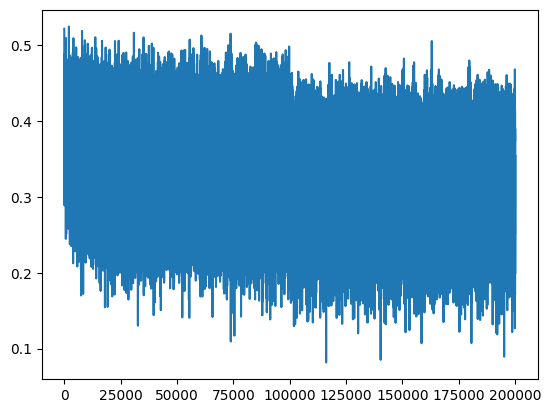

In [24]:
plt.plot(lossi)

In [27]:
split_loss('train')
split_loss('val')

train 2.069589138031006
val 2.1310746669769287


相比于上面没有把`W2`和`b`变小的方案来说，这里的准确率有了提升
```bash
# `W2`和`b`没改变
train 2.122785806655884
val 2.1687753200531006

# `W2`和`b`变小
train 2.069589138031006
val 2.1310746669769287
```

本质上是因为这里其实花了更多的`steps`在优化， 而上面(下图左)可能花了 1w多步骤 来压缩权重（从极端值变到更小的更接近0的值）

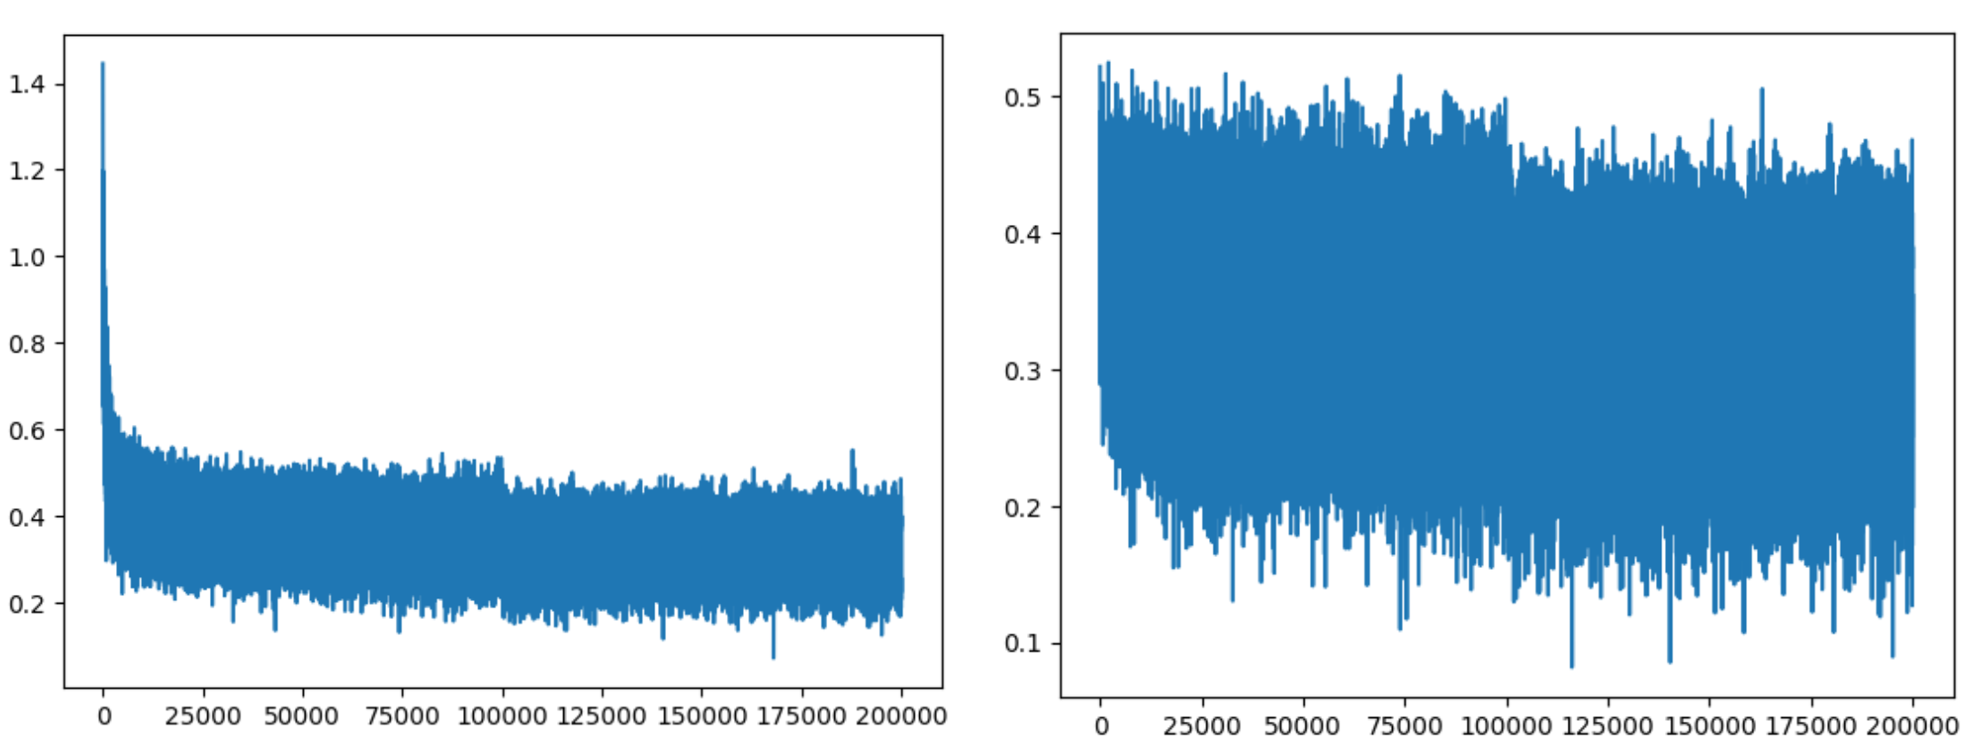

## tanh作为激活函数的影响分析

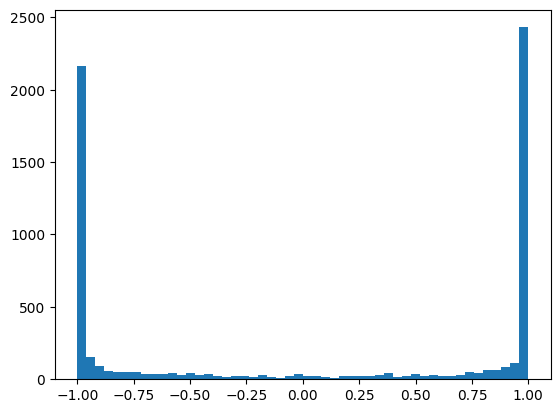

In [29]:
h.view(-1).tolist()
plt.hist(h.view(-1).tolist(), bins=50);
# 如果不加分号, plt.hist() 在画出直方图的同时，会返回一个包含统计信息的元组（如 (n, bins, patches)）。Jupyter 不仅会显示画好的直方图，还会把这串长长的文本数据打印在图表下方，看起来非常杂乱。
# 如果加上分号, 分号在 IPython 中相当于一个“静默符”。它告诉环境：“这行代码结束了，不要自动打印它的返回值”。

```bash
h = torch.tanh(embcat @ W1 + b1) 
```
从上图中可以看出：
1. `h`的大多数值都集中在`1`和`-1`附近， 即：这里的激活函数`tanh`非常活跃，接受的输入都是有效值
2. 从 **plotly(交互式tanh图像)** 中可以看出： 对于`y=tanh(x)`, 当`|x|>2`时, `y≈1`

分析一下`h`在`tanh`之前的一步的情况： 很明显，下图中大多数值分布在[-20, 20]的区间，所以会造成上面`tanh`之后值很多分布在[-1, 1]两个值上

```python
def tanh(self):
    x = self.data
    t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
    out = Value(t, (self,), 'tanh')
    def _backward():
        self.grad += (1 - t**2)*out.grad
    out._backward = _backward
    return out
```

回想之前`micrograd`里，思考：反向传播到$h$这层, 则反向中$h$的下一层梯度就是: $(1 - h^2)\times out.grad$

由于$h$的图像高度集中在[-1,1]这两个值, 就会导致$h.grad = 0$, **梯度直接在这里消失了**~

此外，当$h=0$时($y=tanh(x), x = 0时, y = 0$)，相当于直接传递了$out.grad$到下一层，即：当$y=0$时，即双曲正切函数(tanh)出于非激活状态时，梯度会直接穿透该层

而越靠近tanh的两端，梯度就被压缩的越厉害 → $(1 - h^2)\times out.grad$，即：$h$越大（处在tanh曲线两侧平缓的区间/尾部），则传给下一层的梯度就越小，即：**通过tanh层的梯度只会衰减**

经过`tanh`层后，得到的[-1, 1]越多，则流经该层的梯度就会被削减的越厉害

>**结论**
>
>从这个角度看， `y = tanh(x)`真的不是一个好的激活函数， 一旦输入`x`在[-2,2]之外，输出值`y`就都是[-1,1]
>
>而一旦输出值`y`是[-1,1], 则`y = tanh(x)`这个激活函数的梯度又是`dy/dx = 1-y^2`, 又会直接导致梯度为0，直接导致从这层往后的反向传播过程里乘法/加法操作（应该是大部分op）的梯度失效
>
>可是整个神经网络不管前向还是反向最重要的就是乘法操作啊， `y = Wx+b`, 这就很恶心了~

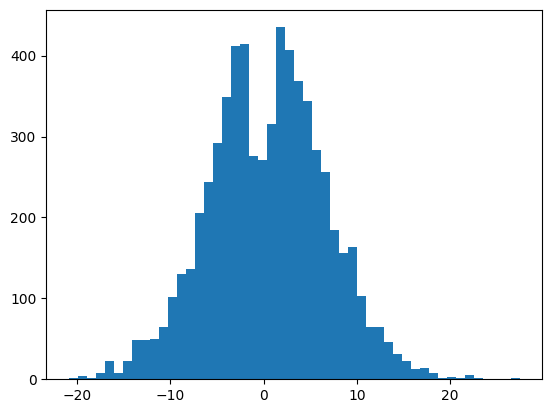

In [34]:
# preact  pre-activations 预激活
hpreact = embcat @ W1 + b1
plt.hist(hpreact.view(-1).tolist(), bins=50);

In [38]:
h.shape  # batch_size = 32, Wx+b  b的维度=200

torch.Size([32, 200])

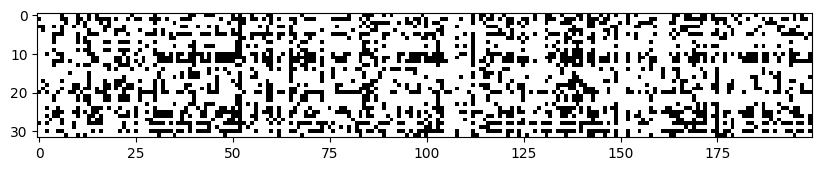

In [39]:
plt.figure(figsize=(10,10))
plt.imshow(h.abs()>0.99, cmap = "gray", interpolation = "nearest")

true 是白色(大于0.99,, 处在tanh的平滑尾部区间) ， false 是黑色 

32行 x 200列

可以看到，白色有很多，即：这些的局部梯度是0，会导致反向传播的梯度从这层开始就消失了（加法和乘法都消失）

如果对于这200个神经元，有一列全都是白色(梯度全是0), 就会出现所谓的死亡神经元(dead neuron), 
+ 有一列全是白色，比如：第5列都是白色，说明这200个神经元里的第5个神经元，在这个批次的32个数据里，没有一个发挥作用，在这个批次里完全没有更新，虽然tanh激活值很高，但是梯度为0，这个神经元就跟死了一样~ 权重一直没有被有效的梯度更新过

In [41]:
indices = torch.where(torch.all(h.abs()>0.99, dim=0))[0]
indices

tensor([ 19,  64, 107, 123, 151, 160, 173])

In [43]:
h[:, 19]

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.9993, 1.0000, 0.9977, 1.0000,
        0.9977, 1.0000, 1.0000, 1.0000, 0.9977, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 0.9997, 0.9977, 0.9977, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 0.9994, 1.0000, 1.0000, 1.0000], grad_fn=<SelectBackward0>)

确实基本全是0， 所以200个神经元里，有7个在这批数据里都是死的~

# 其他

## plotly(交互式tanh图像)

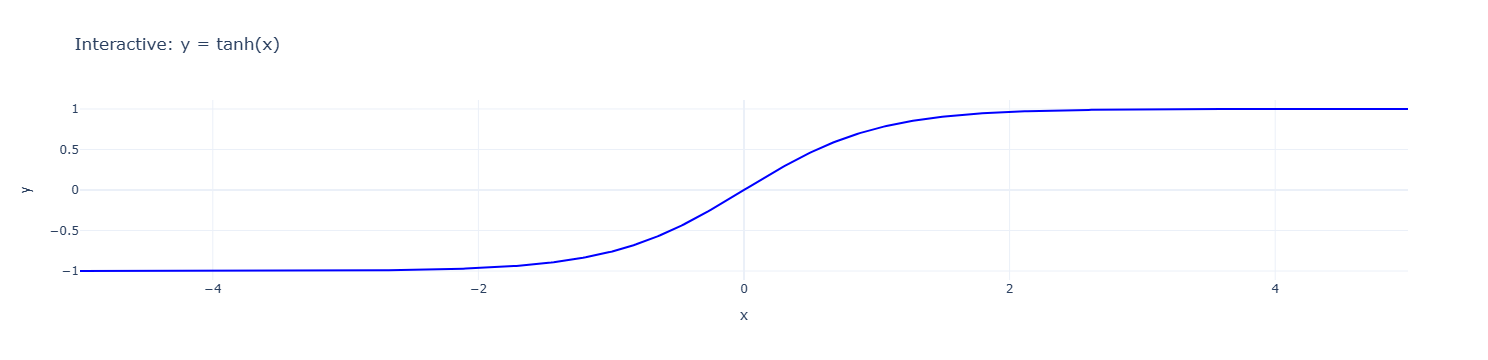

In [36]:
# 安装（首次使用需要）
# !pip install plotly

import plotly.graph_objects as go
import numpy as np

x = np.linspace(-5, 5, 500)
y = np.tanh(x)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x, y=y,
    mode='lines',
    name='tanh(x)',
    line=dict(color='blue', width=2)
))

fig.update_layout(
    title='Interactive: y = tanh(x)',
    xaxis_title='x',
    yaxis_title='y',
    hovermode='x unified',          # 悬停时显示坐标
    template='plotly_white'
)

fig.show()